<a href="https://colab.research.google.com/github/nethmi-i-j/Credit-Risk-Prediction/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import optuna

from sklearn.metrics import (accuracy_score, recall_score, precision_score, classification_report, f1_score, roc_auc_score)

Configuration

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

CSV_PATH = '/content/credit_risk_dataset.csv'
TARGET_COL = 'loan_status'
RANDOM_STATE = 42

Load the dataset

In [ ]:
df = pd.read_csv(CSV_PATH)

In [ ]:
print('Size of the Dataframe : ', df.shape)

Size of the Dataframe :  (32581, 12)


In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4


## 2. Exploratory Data Analysis (EDA)

In [ ]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
# check for missing values

print('Missing vlues per column : ')
df.isna().sum()

Missing vlues per column : 


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


* 895 missing values in person_emp_length and 3116 missing values in loan_int_rate

In [ ]:
print('Unique values in each column')
for col in df.columns:
  print(f'\n{col} :', df[col].unique())



Unique values in each column

person_age : [ 22  21  25  23  24  26 144 123  20  32  34  29  33  28  35  31  27  30
  36  40  50  45  37  39  44  43  41  46  38  47  42  48  49  58  65  51
  53  66  61  54  57  59  62  60  55  52  64  70  78  69  56  73  63  94
  80  84  76  67]

person_income : [  59000    9600   65500 ...  720000 1900000    4888]

person_home_ownership : ['RENT' 'OWN' 'MORTGAGE' 'OTHER']

person_emp_length : [123.   5.   1.   4.   8.   2.   6.   7.   0.   9.   3.  10.  nan  11.
  18.  12.  17.  14.  16.  13.  19.  15.  20.  22.  21.  24.  23.  26.
  25.  27.  28.  31.  41.  34.  29.  38.  30.]

loan_intent : ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

loan_grade : ['D' 'B' 'C' 'A' 'E' 'F' 'G']

loan_amnt : [35000  1000  5500  2500  1600  4500 30000  1750 34800 34000  1500 33950
 33000  4575  1400 32500  4000  2000 32000 31050 24250  7800 20000 10000
 25000 18000 12000 29100 28000  9600  3000  6100  4200  4750  4800  2700
 2760

In [ ]:
for col in df.columns:
  print('\nTop values:', df[col].value_counts().head(20))


Top values: person_age
23    3889
22    3633
24    3549
25    3037
26    2477
27    2138
28    1854
29    1687
30    1316
21    1229
31    1142
32     964
33     856
34     709
35     620
36     548
37     478
38     373
39     302
40     271
Name: count, dtype: int64

Top values: person_income
60000     1046
30000      847
50000      778
40000      658
45000      590
75000      579
65000      532
48000      532
70000      527
42000      524
36000      518
55000      471
80000      448
54000      444
35000      409
90000      390
24000      378
100000     363
120000     355
72000      353
Name: count, dtype: int64

Top values: person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

Top values: person_emp_length
0.000     4105
2.000     3849
3.000     3456
5.000     2946
1.000     2915
4.000     2874
6.000     2666
7.000     2196
8.000     1687
9.000     1367
11.000     740
10.000     696
12.000     575
13.000     426
14.

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.000,NaN,NaN,NaN,27.735,6.348,20.000,23.000,26.000,30.000,144.000
person_income,32581.000,NaN,NaN,NaN,66074.848,61983.119,4000.000,38500.000,55000.000,79200.000,6000000.000
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.000,NaN,NaN,NaN,4.790,4.143,0.000,2.000,4.000,7.000,123.000
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.000,NaN,NaN,NaN,9589.371,6322.087,500.000,5000.000,8000.000,12200.000,35000.000
loan_int_rate,29465.000,NaN,NaN,NaN,11.012,3.240,5.420,7.900,10.990,13.470,23.220
loan_status,32581.000,NaN,NaN,NaN,0.218,0.413,0.000,0.000,0.000,0.000,1.000
loan_percent_income,32581.000,NaN,NaN,NaN,0.170,0.107,0.000,0.090,0.150,0.230,0.830


In [ ]:
# class distribution of target column

df[TARGET_COL].value_counts()

,count
loan_status,
0,25473
1,7108


**Insights :**

1. 895 missing values in person_emp_length and 3116 missing values in loan_int_rate
2. The dataset is imbalanced.

In [ ]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical Columns : ',numerical_columns)
print('Categorical Columns :' , categorical_columns)
print('Target : ',TARGET_COL)

Numerical Columns :  ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical Columns : ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Target :  loan_status


## 3. Data Visualization

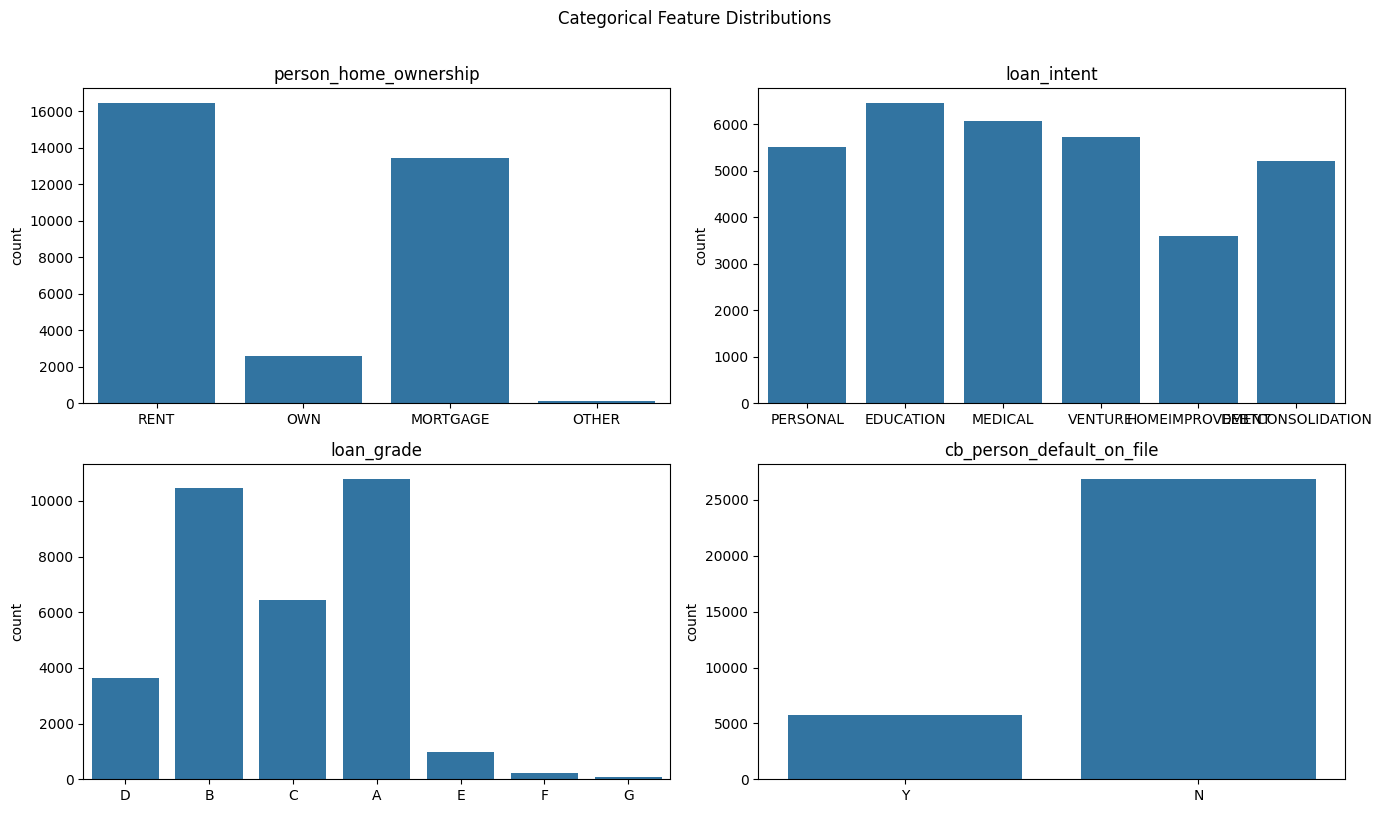

In [ ]:
# count plots for categorical columns

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x')


plt.suptitle('Categorical Feature Distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

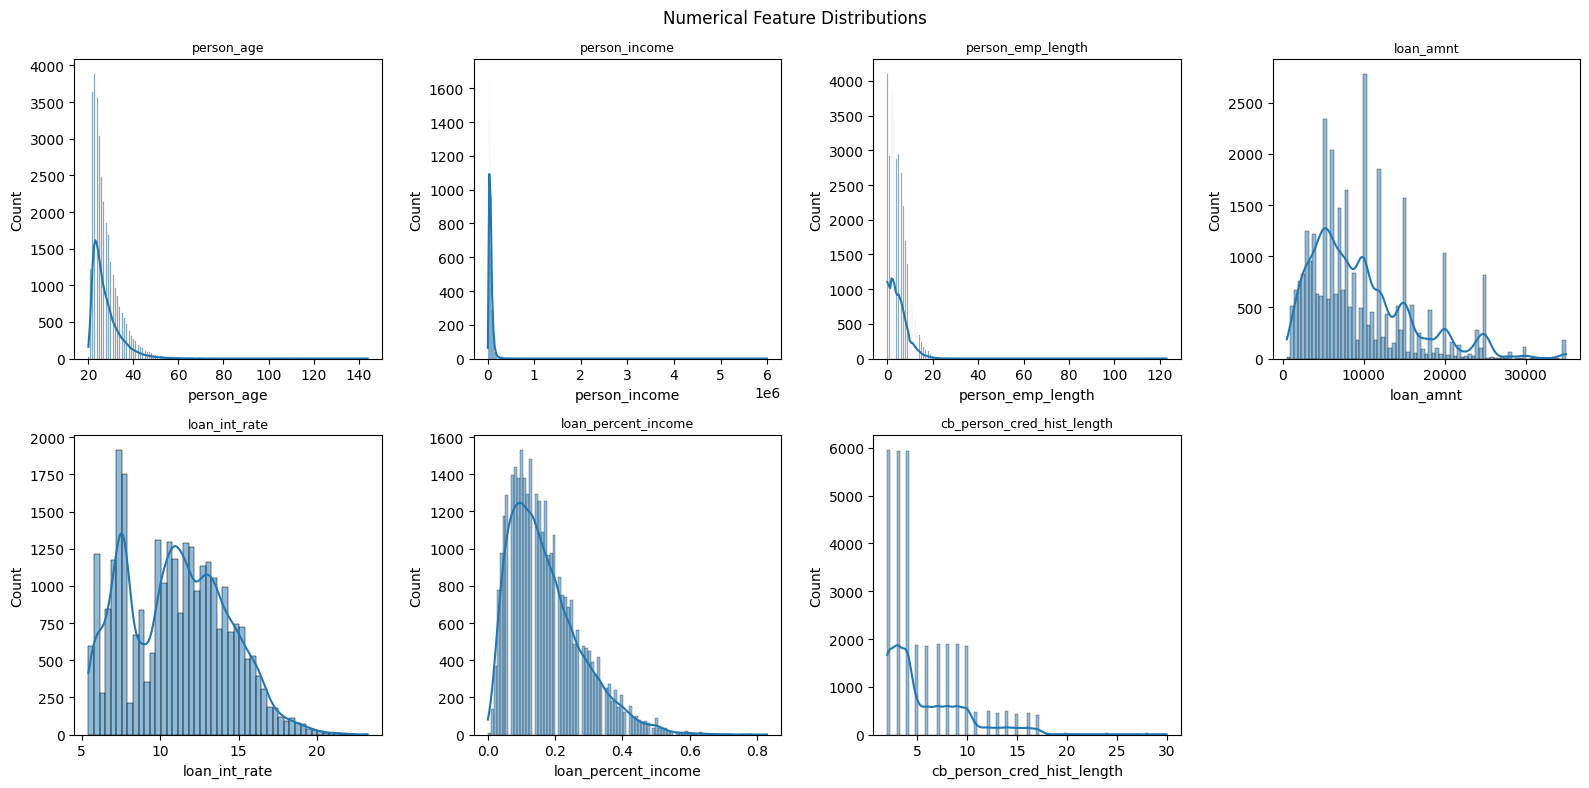

In [ ]:
# histograms for numerical features

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']]):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

fig.delaxes(axes[7])
plt.suptitle('Numerical Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

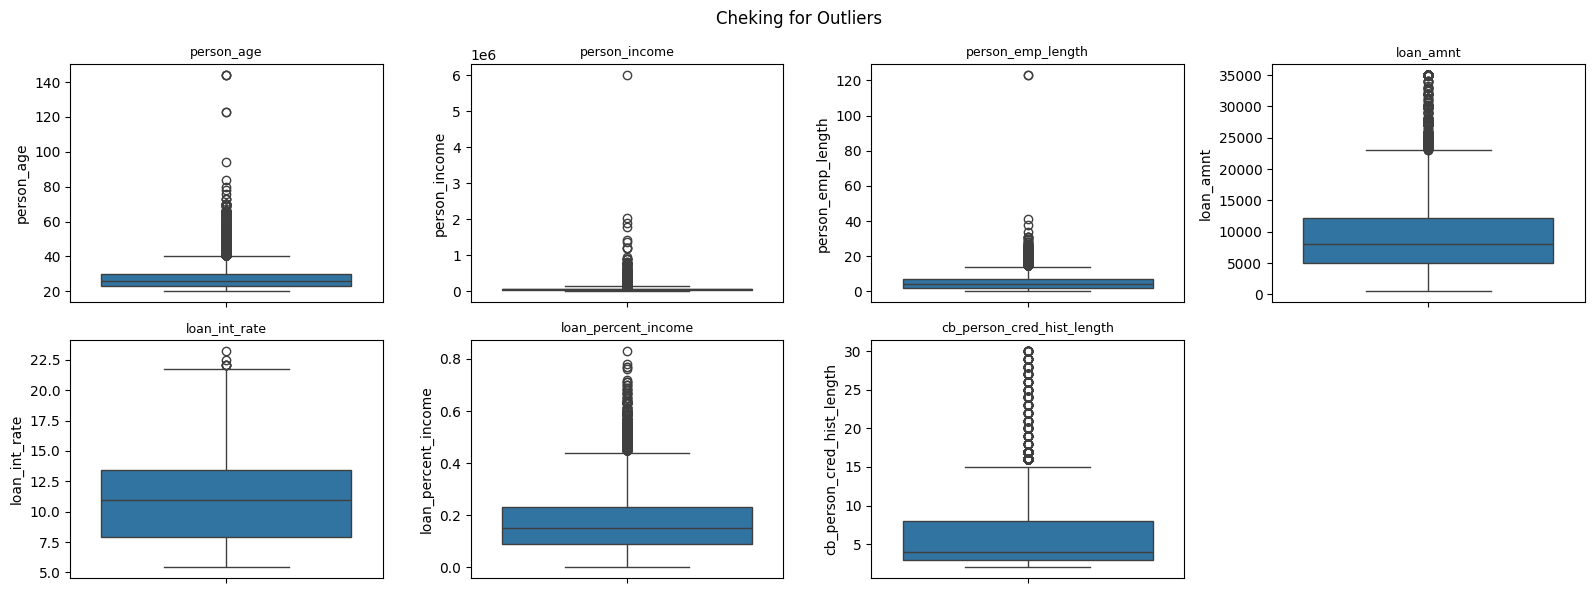

In [ ]:
# boxplots for identify outliers

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']]):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9)

fig.delaxes(axes[7])
plt.suptitle('Cheking for Outliers', fontsize=12)
plt.tight_layout()
plt.show()

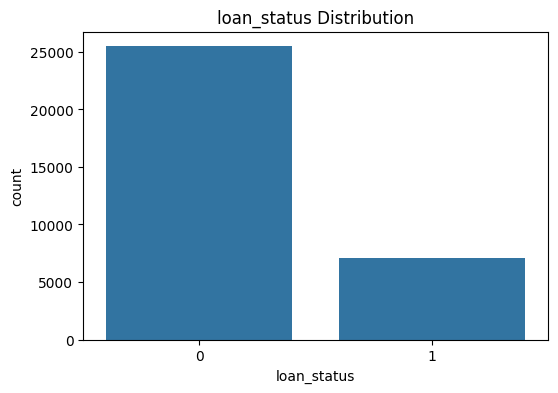

In [ ]:
# Target Distribution

plt.figure(figsize=(6,4))
sns.countplot(x=df[TARGET_COL], data=df)
plt.title('loan_status Distribution')
plt.xlabel(TARGET_COL)
plt.show()

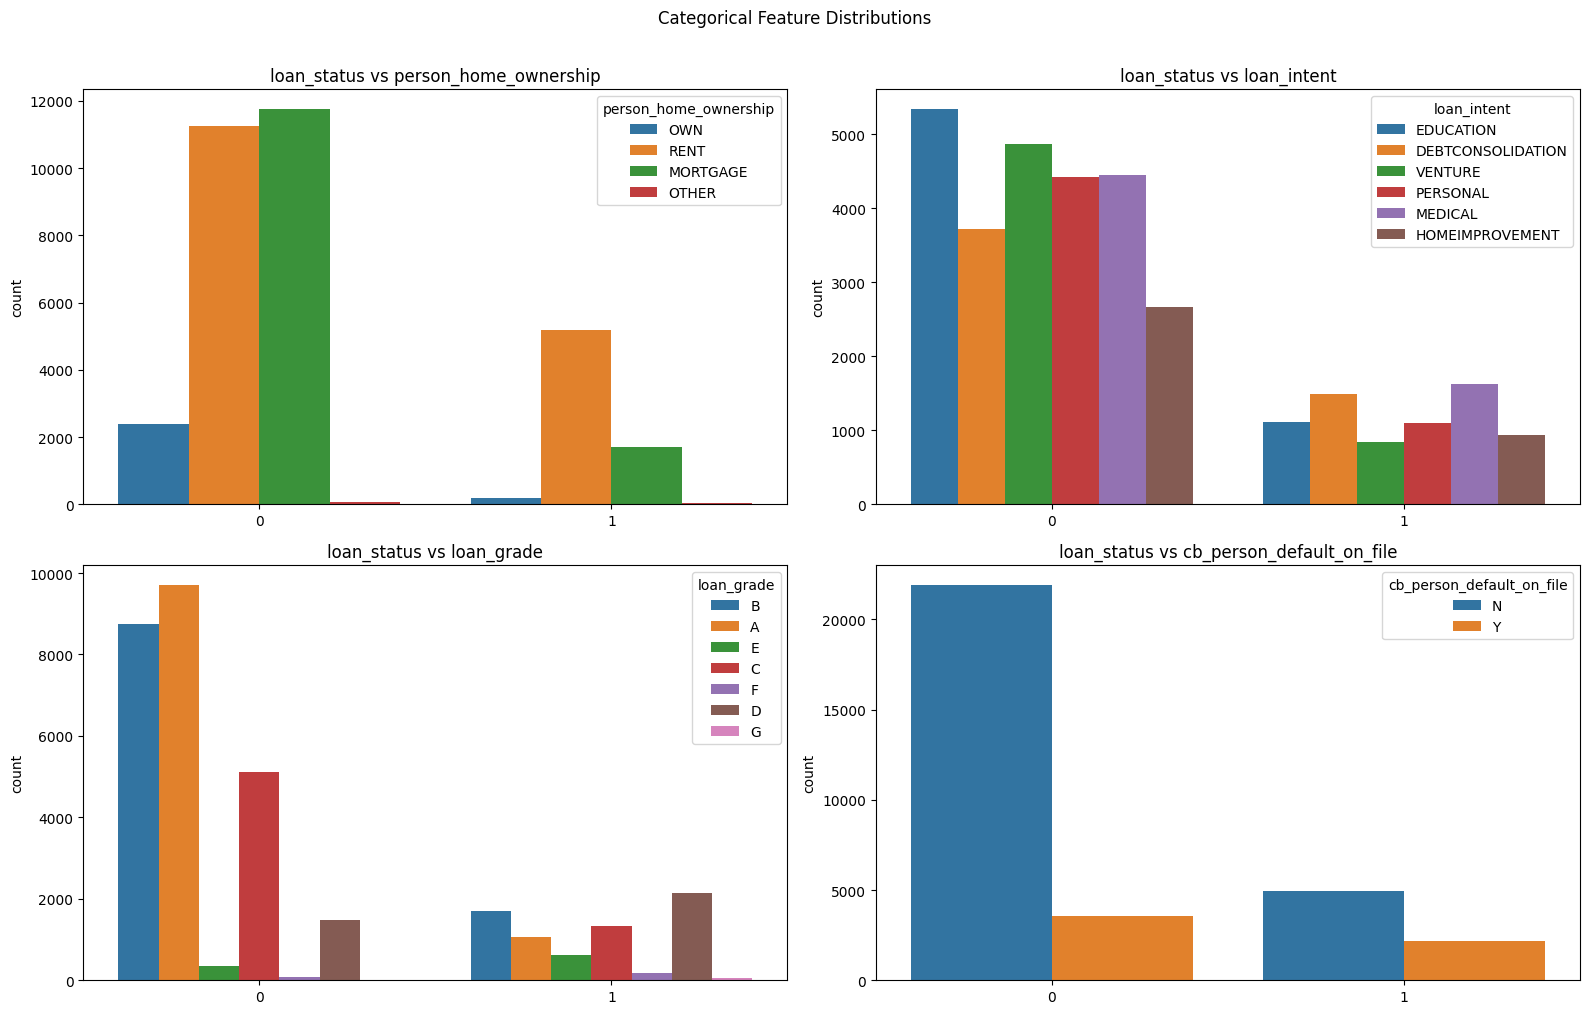

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(x=TARGET_COL, hue=col, data=df, ax=axes[i])
    axes[i].set_title(f'loan_status vs {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x')

plt.suptitle('Categorical Feature Distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

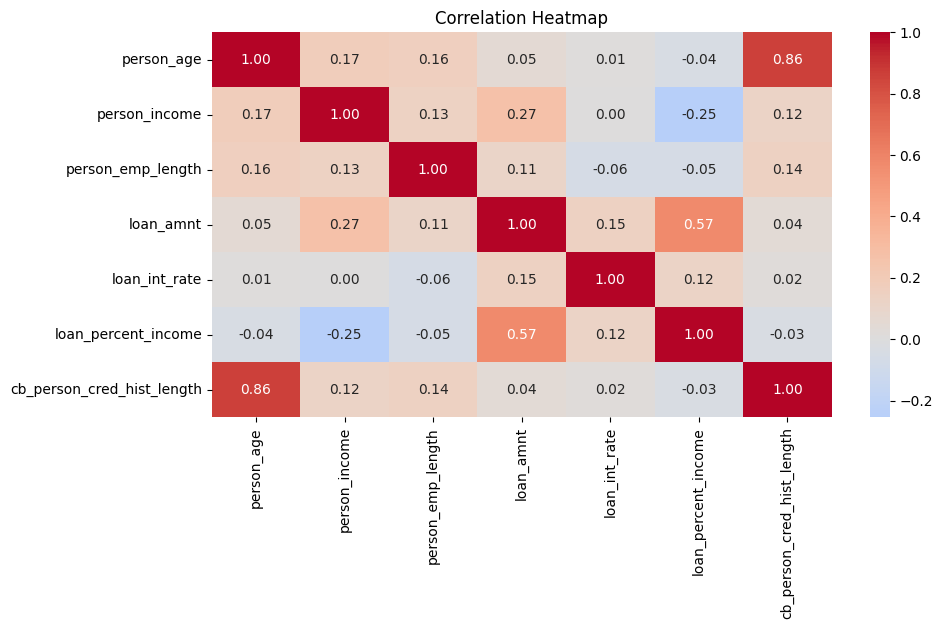

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']].corr(), center=0, fmt='.2f', annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 4. Data Preprocessing

In [ ]:
# handle outliers

print("Before cleaning:", df.shape)
print("Impossible age rows:", (df['person_age'] > 100).sum())
print("Impossible emp_length rows:", (df['person_emp_length'] > 60).sum())



Before cleaning: (32581, 12)
Impossible age rows: 5
Impossible emp_length rows: 2


In [ ]:
# Drop rows with impossible person_age (e.g., 144, 122 etc.)
df = df[df['person_age'] <= 100]

In [ ]:
# Drop rows with impossible person_emp_length (e.g., 120+ years)
df = df[df['person_emp_length'] <= 60]

In [ ]:
print("After cleaning:", df.shape)

After cleaning: (31679, 12)


In [ ]:
X = df.drop(columns=TARGET_COL)
Y = df[TARGET_COL]

In [ ]:
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,0.550,Y,4
5,21,9900,OWN,2.000,VENTURE,A,2500,7.140,0.250,N,2


In [ ]:
Y.head()

,loan_status
1,0
2,1
3,1
4,1
5,1


In [ ]:
df[TARGET_COL].value_counts()

,count
loan_status,
0,24854
1,6825


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=RANDOM_STATE)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(25343, 11)
(6336, 11)


In [ ]:
print(Y_train.value_counts())

loan_status
0    19883
1     5460
Name: count, dtype: int64


Preprocessing Pipeline

In [ ]:

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print('numerical features : ', num_features)
print('categorical_features : ', cat_features)

numerical_transformer = Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='median')),
        ('scale',StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('encode',OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

numerical features :  ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_features :  ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


Synthetic Minority Oversampling Technique (SMOTE) ---> Automatically identifies minority class (1) and oversample it such that it also have equal number of value count like as majority class.

## 5. Model Selection & Evaluation

In [ ]:
models = {
    'LogisticRegression': LogisticRegression(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE)

}

In [ ]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
scoring = {
    'accuracy'          : 'accuracy',
    'f1'                : 'f1',
    'precision'         : 'precision',
    'recall'            : 'recall',
    'roc_auc'           : 'roc_auc'

}

In [ ]:
rows = []

for name, model in models.items():

    pipe = ImbPipeline(
        steps=[
            ('preprocess', preprocess),
            ('smote',SMOTE(random_state=RANDOM_STATE)),
            ('model', model)
        ]
    )

    scores = cross_validate(
        pipe,
        X_train,
        Y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    rows.append({
        'Model': name,

        'Accuracy': scores['test_accuracy'].mean(),
        'F1': scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'ROC-AUC' : scores['test_roc_auc'].mean()


    })

cv_results = pd.DataFrame(rows).sort_values(by='ROC-AUC', ascending=False)

In [ ]:
print("=== CV Model Comparison ===")

print(cv_results)

=== CV Model Comparison ===
                Model  Accuracy    F1  Precision  Recall  ROC-AUC
3             XGBoost     0.934 0.827      0.951   0.732    0.944
2       Random Forest     0.929 0.815      0.926   0.727    0.928
0  LogisticRegression     0.812 0.639      0.545   0.773    0.870
1       Decision Tree     0.868 0.715      0.668   0.769    0.832


In [ ]:
cv_results

,Model,Accuracy,F1,Precision,Recall,ROC-AUC
3,XGBoost,0.934,0.827,0.951,0.732,0.944
2,Random Forest,0.929,0.815,0.926,0.727,0.928
0,LogisticRegression,0.812,0.639,0.545,0.773,0.870
1,Decision Tree,0.868,0.715,0.668,0.769,0.832


Hyperparameter Tunning

In [ ]:
def objective(trial):

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 5.0),
    }

    xg_pipe = ImbPipeline(steps=[
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', XGBClassifier(
            **params,
            random_state=RANDOM_STATE,
            eval_metric='logloss'
        ))
    ])


    scores = cross_val_score(
        xg_pipe, X_train, Y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    return scores.mean()


# --- Run the study ---
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=False)

# --- Results ---
print("Best ROC-AUC:", study.best_value)
print("Best params: ", study.best_params)

[I 2026-08-01 06:00:35,497] A new study created in memory with name: no-name-9df63682-becd-4cb0-9e71-795e594a52a9
[I 2026-08-01 06:00:48,573] Trial 0 finished with value: 0.9365810663296547 and parameters: {'n_estimators': 722, 'learning_rate': 0.12076908972434813, 'max_depth': 5, 'subsample': 0.5962287191626083, 'colsample_bytree': 0.6449275600147759, 'min_child_weight': 2, 'gamma': 2.875624464523543, 'reg_alpha': 3.2991089515091474, 'reg_lambda': 3.4493007796946706}. Best is trial 0 with value: 0.9365810663296547.
[I 2026-08-01 06:01:02,261] Trial 1 finished with value: 0.9435878408378894 and parameters: {'n_estimators': 674, 'learning_rate': 0.15144603515547203, 'max_depth': 10, 'subsample': 0.9682676440510334, 'colsample_bytree': 0.5948505247142423, 'min_child_weight': 7, 'gamma': 0.3368763765219468, 'reg_alpha': 3.0242386000359023, 'reg_lambda': 4.919650334583828}. Best is trial 1 with value: 0.9435878408378894.
[I 2026-08-01 06:01:29,725] Trial 2 finished with value: 0.9442284556

Best ROC-AUC: 0.94496221295607
Best params:  {'n_estimators': 796, 'learning_rate': 0.0974721850761755, 'max_depth': 5, 'subsample': 0.6704563202858058, 'colsample_bytree': 0.8999935080502518, 'min_child_weight': 1, 'gamma': 1.826869531934511, 'reg_alpha': 1.0550578941137865, 'reg_lambda': 0.6661531495368178}


In [ ]:
best_pipe = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', XGBClassifier(
        **study.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

best_pipe.fit(X_train, Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most...
                               gamma=1.826869531934511, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.0974721850761755, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=1, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=796, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
train_pred  = best_pipe.predict(X_train)
test_pred   = best_pipe.predict(X_test)
train_proba = best_pipe.predict_proba(X_train)[:, 1]
test_proba  = best_pipe.predict_proba(X_test)[:, 1]

print("=== Final Evaluation — Tuned XGBoost Classifier ===\n")

print("Training")
print("--------")
print(f"Accuracy  : {accuracy_score(Y_train, train_pred):.4f}")
print(f"Precision : {precision_score(Y_train, train_pred):.4f}")
print(f"Recall    : {recall_score(Y_train, train_pred):.4f}")
print(f"F1        : {f1_score(Y_train, train_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(Y_train, train_proba):.4f}")

print("\nTesting")
print("-------")
print(f"Accuracy  : {accuracy_score(Y_test, test_pred):.4f}")
print(f"Precision : {precision_score(Y_test, test_pred):.4f}")
print(f"Recall    : {recall_score(Y_test, test_pred):.4f}")
print(f"F1        : {f1_score(Y_test, test_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(Y_test, test_proba):.4f}")
print(f"Overfit gap (Accuracy): {accuracy_score(Y_train, train_pred) - accuracy_score(Y_test, test_pred):.4f}")

print("\nClassification Report")
print("---------------------")
print(classification_report(Y_test, test_pred, target_names=['Not Default', 'Default']))

=== Final Evaluation — Tuned XGBoost Classifier ===

Training
--------
Accuracy  : 0.9466
Precision : 0.9851
Recall    : 0.7636
F1        : 0.8603
ROC-AUC   : 0.9787

Testing
-------
Accuracy  : 0.9388
Precision : 0.9657
Recall    : 0.7421
F1        : 0.8393
ROC-AUC   : 0.9505
Overfit gap (Accuracy): 0.0078

Classification Report
---------------------
              precision    recall  f1-score   support

 Not Default       0.93      0.99      0.96      4971
     Default       0.97      0.74      0.84      1365

    accuracy                           0.94      6336
   macro avg       0.95      0.87      0.90      6336
weighted avg       0.94      0.94      0.94      6336



In [ ]:
## 8. Threshold Tuning

proba = best_pipe.predict_proba(X_test)[:, 1]

print('Threshold Tuning for XGBoost')
print('-' * 44)
print(f'{"Thresh":<10}{"Precision":<12}{"Recall":<10}{"F1":<8}')
print('-' * 44)

for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec  = precision_score(Y_test, preds, pos_label=1)
    rec   = recall_score(Y_test, preds, pos_label=1)
    f1    = f1_score(Y_test, preds, pos_label=1)
    print(f'{thresh:<10}{prec:<12.3f}{rec:<10.3f}{f1:<8.3f}')

print('-' * 44)

Threshold Tuning for XGBoost
--------------------------------------------
Thresh    Precision   Recall    F1      
--------------------------------------------
0.25      0.800       0.815     0.807   
0.3       0.865       0.786     0.824   
0.35      0.897       0.775     0.831   
0.4       0.923       0.760     0.834   
0.45      0.946       0.751     0.837   
0.5       0.966       0.742     0.839   
--------------------------------------------


In [ ]:
threshold = 0.25
Y_pred = (proba >= threshold).astype(int)


**Since main objective is to identify who more likely to have credit risk (Defaulted) should shoose the highest recall. So suitable threshold would be 0.25.**

In [ ]:
print(classification_report(Y_test, Y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.949     0.944     0.946      4971
           1      0.800     0.815     0.807      1365

    accuracy                          0.916      6336
   macro avg      0.874     0.880     0.877      6336
weighted avg      0.917     0.916     0.916      6336



In [ ]:
# --- Apply Best Threshold ---

y_pred_tuned = (test_proba >= threshold).astype(int)

print("\n=== Evaluation with Tuned Threshold ===\n")
print(f"Threshold  : {threshold:.4f}")
print(f"Accuracy   : {accuracy_score(Y_test, y_pred_tuned):.4f}")
print(f"Precision  : {precision_score(Y_test, y_pred_tuned):.4f}")
print(f"Recall     : {recall_score(Y_test, y_pred_tuned):.4f}")
print(f"F1         : {f1_score(Y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC    : {roc_auc_score(Y_test, test_proba):.4f}")

print("\nClassification Report")
print("---------------------")
print(classification_report(Y_test, y_pred_tuned, target_names=['Not Default', 'Default']))


=== Evaluation with Tuned Threshold ===

Threshold  : 0.2500
Accuracy   : 0.9162
Precision  : 0.7996
Recall     : 0.8154
F1         : 0.8074
ROC-AUC    : 0.9505

Classification Report
---------------------
              precision    recall  f1-score   support

 Not Default       0.95      0.94      0.95      4971
     Default       0.80      0.82      0.81      1365

    accuracy                           0.92      6336
   macro avg       0.87      0.88      0.88      6336
weighted avg       0.92      0.92      0.92      6336



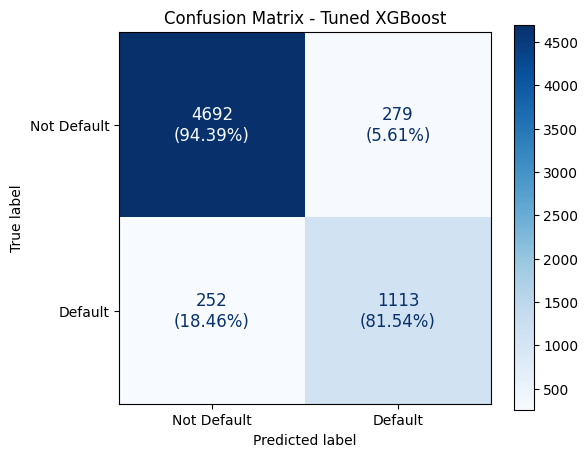

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, y_pred_tuned)

cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

labels = np.array([
    [f"{cm[i,j]}\n({cm_percent[i,j]:.2f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Default', 'Default']
)

disp.plot(cmap='Blues', ax=ax, values_format='')

# Replace default numbers with count + percentage
for text, label in zip(ax.texts, labels.flatten()):
    text.set_text(label)
    text.set_fontsize(12)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

## 6. Model Interpretability (SHAP)

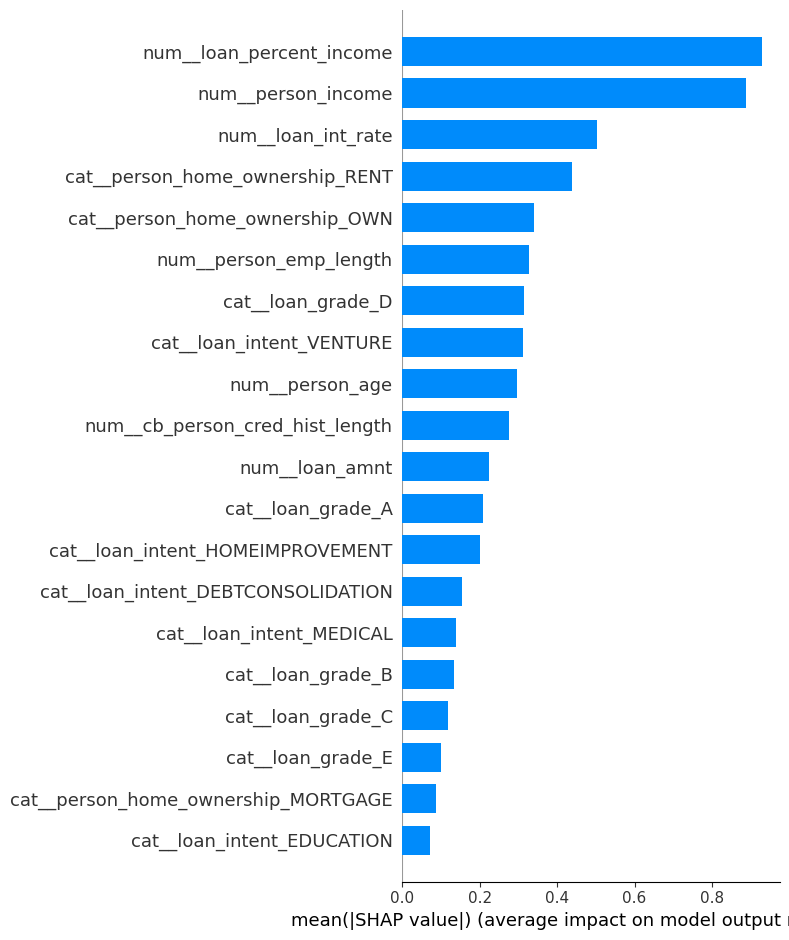

In [ ]:
import shap

preprocessor = best_pipe.named_steps['preprocess']
xgb_model    = best_pipe.named_steps['model']

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

# Get readable feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_transformed, columns=feature_names)

# TreeExplainer is fast and exact for XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

# Global view: which features matter most overall
shap.summary_plot(shap_values, X_test_df, plot_type='bar')





According to the SHAP Summary plot, loan_persant_income is the highly effected feature for the overall prediction.

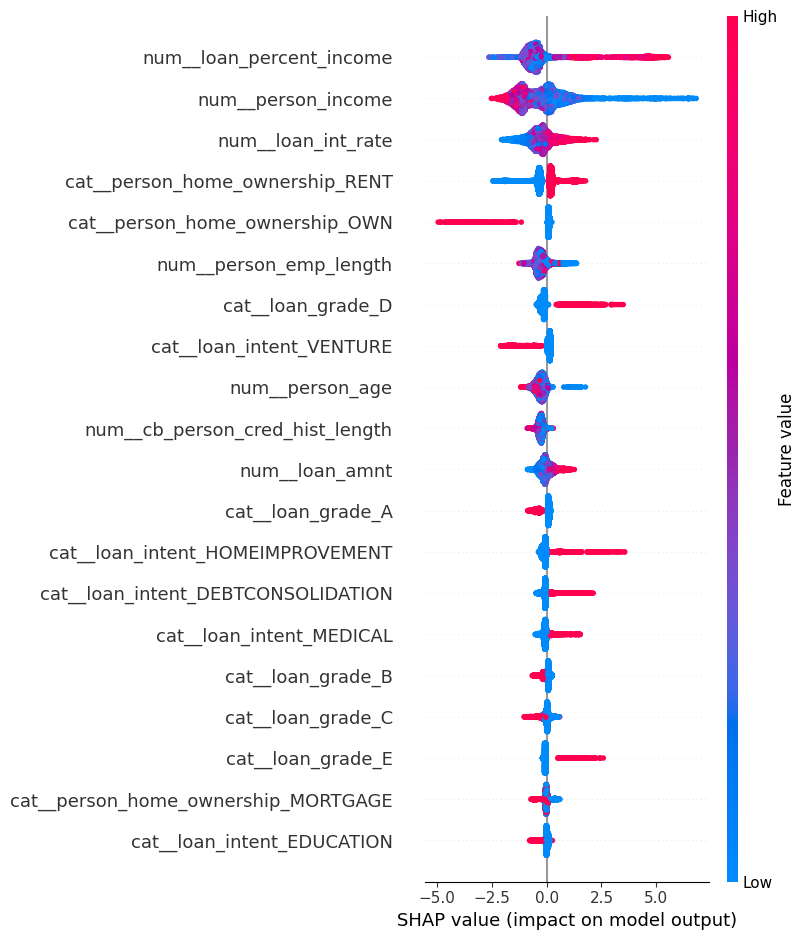

In [ ]:
# Full distribution view
shap.summary_plot(shap_values, X_test_df)

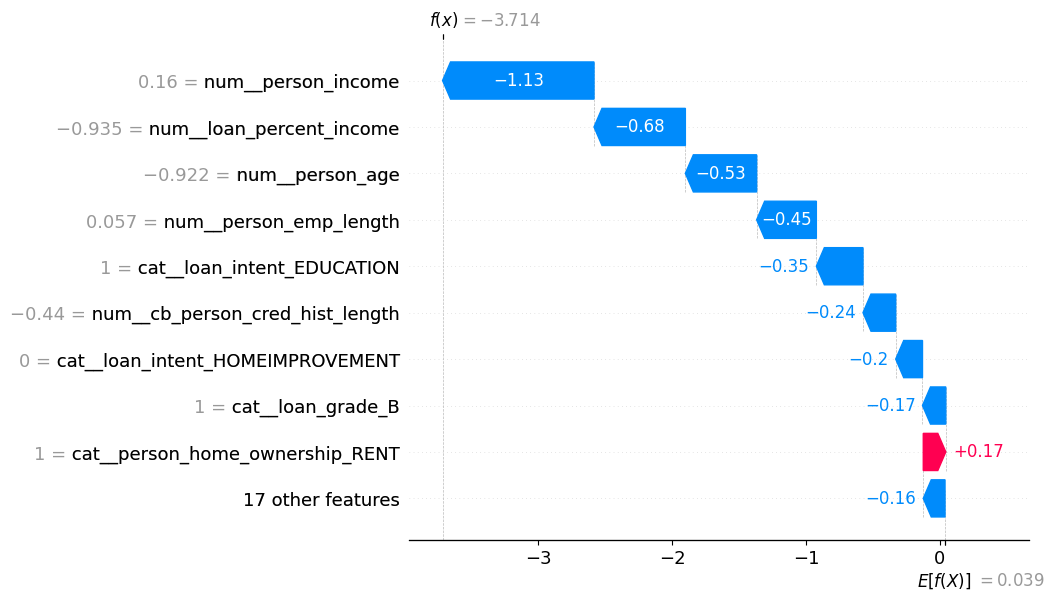

In [ ]:
# One applicant's explanation (e.g. row 0)
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[0],
    feature_names=feature_names
))

In [ ]:
import joblib

# Bundle everything into one object
model_bundle = {
    'pipeline': best_pipe,
    'feature_names': feature_names,
    'threshold': threshold
}

joblib.dump(model_bundle, 'credit_risk.pkl')

from google.colab import files
files.download('credit_risk.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>